# 🧠 Deep Learning Architectures - Partie 1
## Architectures de Réseaux de Neurones et Modalités

### 🎯 Objectifs
- Comprendre les différentes architectures de réseaux de neurones
- Identifier les modalités de données (texte, image, son, multimodal)
- Savoir choisir l'architecture selon le problème
- Comprendre l'évolution historique du deep learning

---
*Session 05 - Continuation - SupNum Nouakchott - Formation IA & Machine Learning*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display, HTML, Image as IPImage
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("🧠 Deep Learning Architectures Guide - Partie 1")
print("=" * 50)

🧠 Deep Learning Architectures Guide - Partie 1


## 📚 1. Rappel : Où nous en sommes

### ✅ Ce que nous avons vu dans les parties précédentes :
- **Partie 0** : Introduction théorique aux réseaux de neurones
- **Partie 1** : Perceptron et concepts de base
- **Partie 2** : Réseaux multi-couches (MLP) et backpropagation
- **Partie 3** : Applications pratiques avec datasets réels

### 🚀 Ce que nous allons voir maintenant :
- **Partie 1 (actuelle)** : Architectures spécialisées et modalités
- **Partie 2 (suivante)** : Hardware, Transfer Learning, Transformers et benchmarks

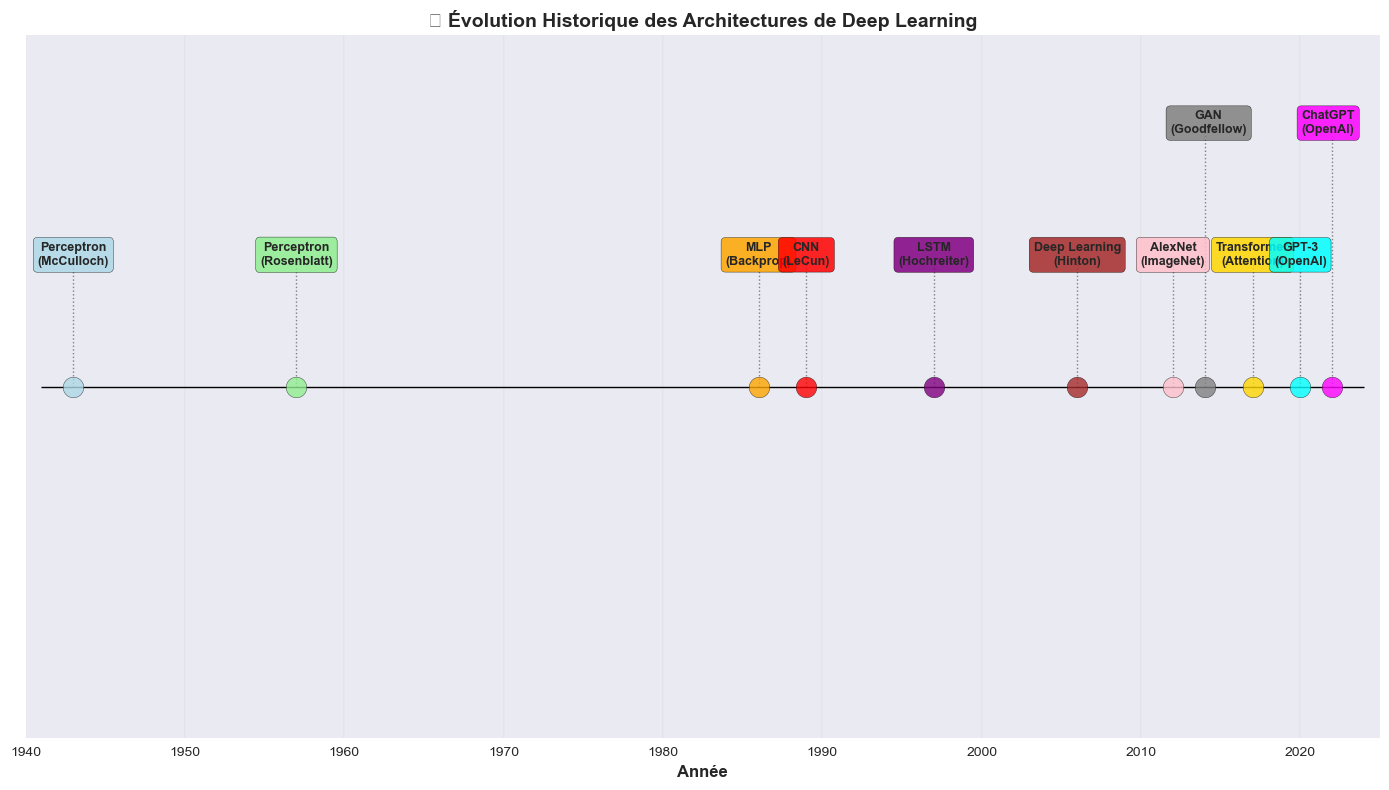

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Données
years = [1943, 1957, 1986, 1989, 1997, 2006, 2012, 2014, 2017, 2020, 2022]
architectures = [
    'Perceptron\n(McCulloch)', 'Perceptron\n(Rosenblatt)', 'MLP\n(Backprop)',
    'CNN\n(LeCun)', 'LSTM\n(Hochreiter)', 'Deep Learning\n(Hinton)',
    'AlexNet\n(ImageNet)', 'GAN\n(Goodfellow)', 'Transformer\n(Attention)',
    'GPT-3\n(OpenAI)', 'ChatGPT\n(OpenAI)'
]
colors = ['lightblue', 'lightgreen', 'orange', 'red', 'purple',
          'brown', 'pink', 'gray', 'gold', 'cyan', 'magenta']

# --- Paramètres anti-overlap ---
y_timeline = 1.0                                # ligne de temps
lanes = [0.70, 0.85, 1.15, 1.30]                # positions d'affichage des labels
lane_idx = 0
min_gap = 2                                      # si 2 ans ou moins d'écart → change de "lane"

# petite fonction qui choisit une lane pour réduire les collisions temporelles
assigned_y = []
for i, yr in enumerate(years):
    if i > 0 and (yr - years[i-1]) <= min_gap:
        lane_idx = (lane_idx + 1) % len(lanes)   # alterner les lignes proches temporellement
    else:
        # revient à une lane centrale pour les points espacés
        lane_idx = 2
    assigned_y.append(lanes[lane_idx])

# Décalage horizontal subtil pour séparer encore les boîtes proches
x_jitter = np.zeros(len(years))
for i in range(1, len(years)):
    if abs(years[i] - years[i-1]) <= min_gap:
        x_jitter[i] = (0.25 if (i % 2) else -0.25)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 8))

# ligne de temps
ax.hlines(y=y_timeline, xmin=min(years)-2, xmax=max(years)+2, color='k', lw=1)

# points + annotations
for year, arch, color, y_lab, dx in zip(years, architectures, colors, assigned_y, x_jitter):
    # point sur la timeline
    ax.scatter(year, y_timeline, s=220, c=color, alpha=0.8, edgecolors='black', zorder=3)

    # trait de liaison vers la boîte
    ax.vlines(x=year, ymin=min(y_timeline, y_lab), ymax=max(y_timeline, y_lab),
              color='gray', lw=1, ls=':', zorder=1)

    # annotation (boîte) légèrement décalée en x si nécessaire
    ax.annotate(
        arch,
        xy=(year, y_lab),
        xytext=(year + dx, y_lab),
        textcoords='data',
        ha='center', va='center',
        fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', facecolor=color, alpha=0.85, edgecolor='black')
    )

# axes & style
ax.set_xlim(1940, 2025)
ax.set_ylim(0.6, 1.4)
ax.set_xlabel('Année', fontsize=12, fontweight='bold')
ax.set_title('🕐 Évolution Historique des Architectures de Deep Learning', fontsize=14, fontweight='bold')
ax.set_yticks([])
ax.grid(axis='x', alpha=0.25)

# repères décennaux (facultatif)
for decade in range(1940, 2030, 10):
    ax.axvline(decade, color='k', lw=0.3, alpha=0.15)

plt.tight_layout()
plt.show()


## 🏗️ 2. Architectures de Réseaux de Neurones

### 🎯 Principe Fondamental
Chaque architecture est **spécialisée** pour un type de données et de problème spécifique.

> **Règle d'or** : L'architecture doit correspondre à la **structure** et aux **propriétés** de vos données.

🏗️ ARCHITECTURES DE RÉSEAUX DE NEURONES


,Architecture,Type de Données,Problème Principal,Année,Complexité
0,MLP (Dense),Tabulaires,Classification/Régression,1986,Faible
1,CNN,Images,Vision,1989,Moyenne
2,RNN/LSTM,Séquences,Séries temporelles,1997,Élevée
3,Transformer,Texte/Séquences,NLP,2017,Très élevée
4,GAN,Génération,Création,2014,Élevée
5,VAE,Génération,Compression,2013,Élevée
6,ResNet,Images,Classification,2015,Moyenne
7,U-Net,Segmentation,Segmentation,2015,Moyenne


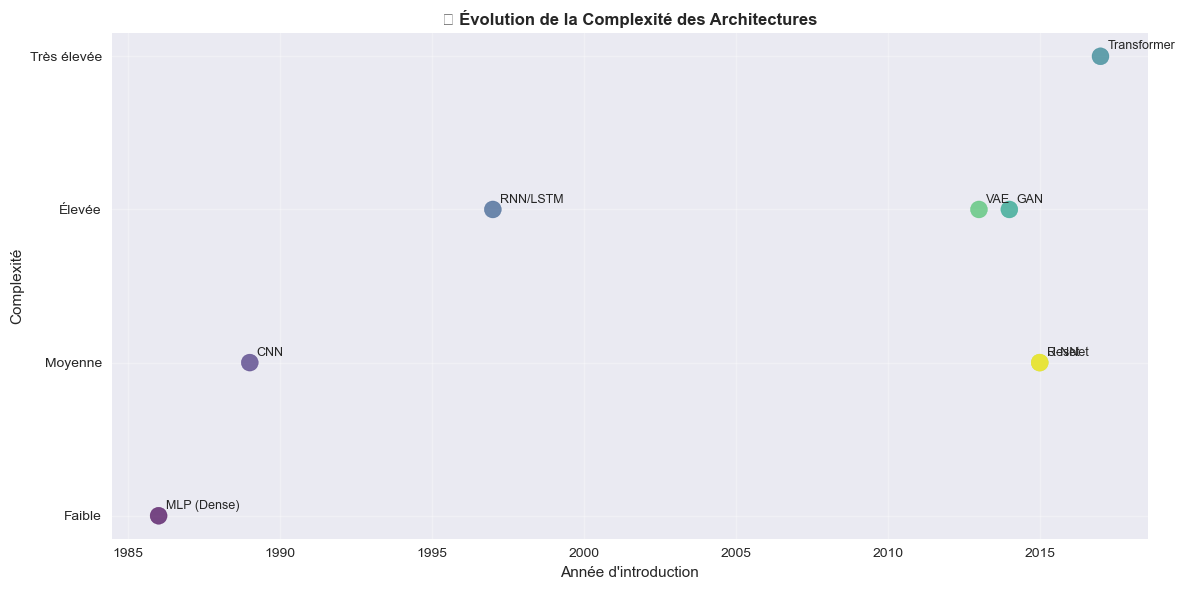

In [3]:
# Tableau comparatif des architectures principales
architectures_data = {
    'Architecture': ['MLP (Dense)', 'CNN', 'RNN/LSTM', 'Transformer', 'GAN', 'VAE', 'ResNet', 'U-Net'],
    'Type de Données': ['Tabulaires', 'Images', 'Séquences', 'Texte/Séquences', 'Génération', 'Génération', 'Images', 'Segmentation'],
    'Problème Principal': ['Classification/Régression', 'Vision', 'Séries temporelles', 'NLP', 'Création', 'Compression', 'Classification', 'Segmentation'],
    'Année': [1986, 1989, 1997, 2017, 2014, 2013, 2015, 2015],
    'Complexité': ['Faible', 'Moyenne', 'Élevée', 'Très élevée', 'Élevée', 'Élevée', 'Moyenne', 'Moyenne']
}

df_architectures = pd.DataFrame(architectures_data)
print("🏗️ ARCHITECTURES DE RÉSEAUX DE NEURONES")
print("=" * 60)
display(df_architectures)

# Graphique de complexité vs année
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

complexity_map = {'Faible': 1, 'Moyenne': 2, 'Élevée': 3, 'Très élevée': 4}
df_architectures['Complexité_num'] = df_architectures['Complexité'].map(complexity_map)

scatter = ax.scatter(df_architectures['Année'], df_architectures['Complexité_num'], 
                    s=150, alpha=0.7, c=range(len(df_architectures)), cmap='viridis')

for i, arch in enumerate(df_architectures['Architecture']):
    ax.annotate(arch, (df_architectures['Année'].iloc[i], df_architectures['Complexité_num'].iloc[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax.set_xlabel('Année d\'introduction')
ax.set_ylabel('Complexité')
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(['Faible', 'Moyenne', 'Élevée', 'Très élevée'])
ax.set_title('📊 Évolution de la Complexité des Architectures', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- **MLP** : *Multi-Layer Perceptron*  
- **CNN** : *Convolutional Neural Network*  
- **RNN** : *Recurrent Neural Network*  
- **LSTM** : *Long Short-Term Memory*  
- **GAN** : *Generative Adversarial Network*  
- **VAE** : *Variational AutoEncoder*  
- **ResNet** : *Residual Network*  
- **U-Net** : Nom inspiré de sa forme en "U" (réseau de neurones convolutifs pour la segmentation).  
- **NLP** (lié à Transformer) : *Natural Language Processing*  


- **MLP (Dense, 1986)** : Réseaux de neurones entièrement connectés utilisés pour la classification et la régression sur données tabulaires.  
- **CNN (1989)** : Réseaux de neurones convolutifs spécialisés pour l’analyse d’images et la vision par ordinateur.  
- **RNN/LSTM (1997)** : Réseaux récurrents capables de modéliser les dépendances dans les séquences et séries temporelles.  
- **Transformer (2017)** : Architecture à base d’attention, devenue standard en NLP et adaptée à d’autres types de données séquentielles.  
- **GAN (2014)** : Réseaux adversariaux génératifs capables de créer de nouvelles données réalistes (images, sons, etc.).  
- **VAE (2013)** : Autoencodeurs variationnels utilisés pour la génération et la compression de données latentes.  
- **ResNet (2015)** : Réseaux profonds avec connexions résiduelles facilitant l’entraînement de très nombreux niveaux.  
- **U-Net (2015)** : Architecture en forme de U conçue pour la segmentation d’images, très utilisée en biomédical.  


## 🎨 3. Modalités de Données et Architectures Associées

### 🔍 Qu'est-ce qu'une modalité ?
Une **modalité** est un type de données avec ses propres caractéristiques :
- **Structure** (1D, 2D, 3D)
- **Propriétés** (temporel, spatial, fréquentiel)
- **Représentation** (pixels, mots, ondes sonores)

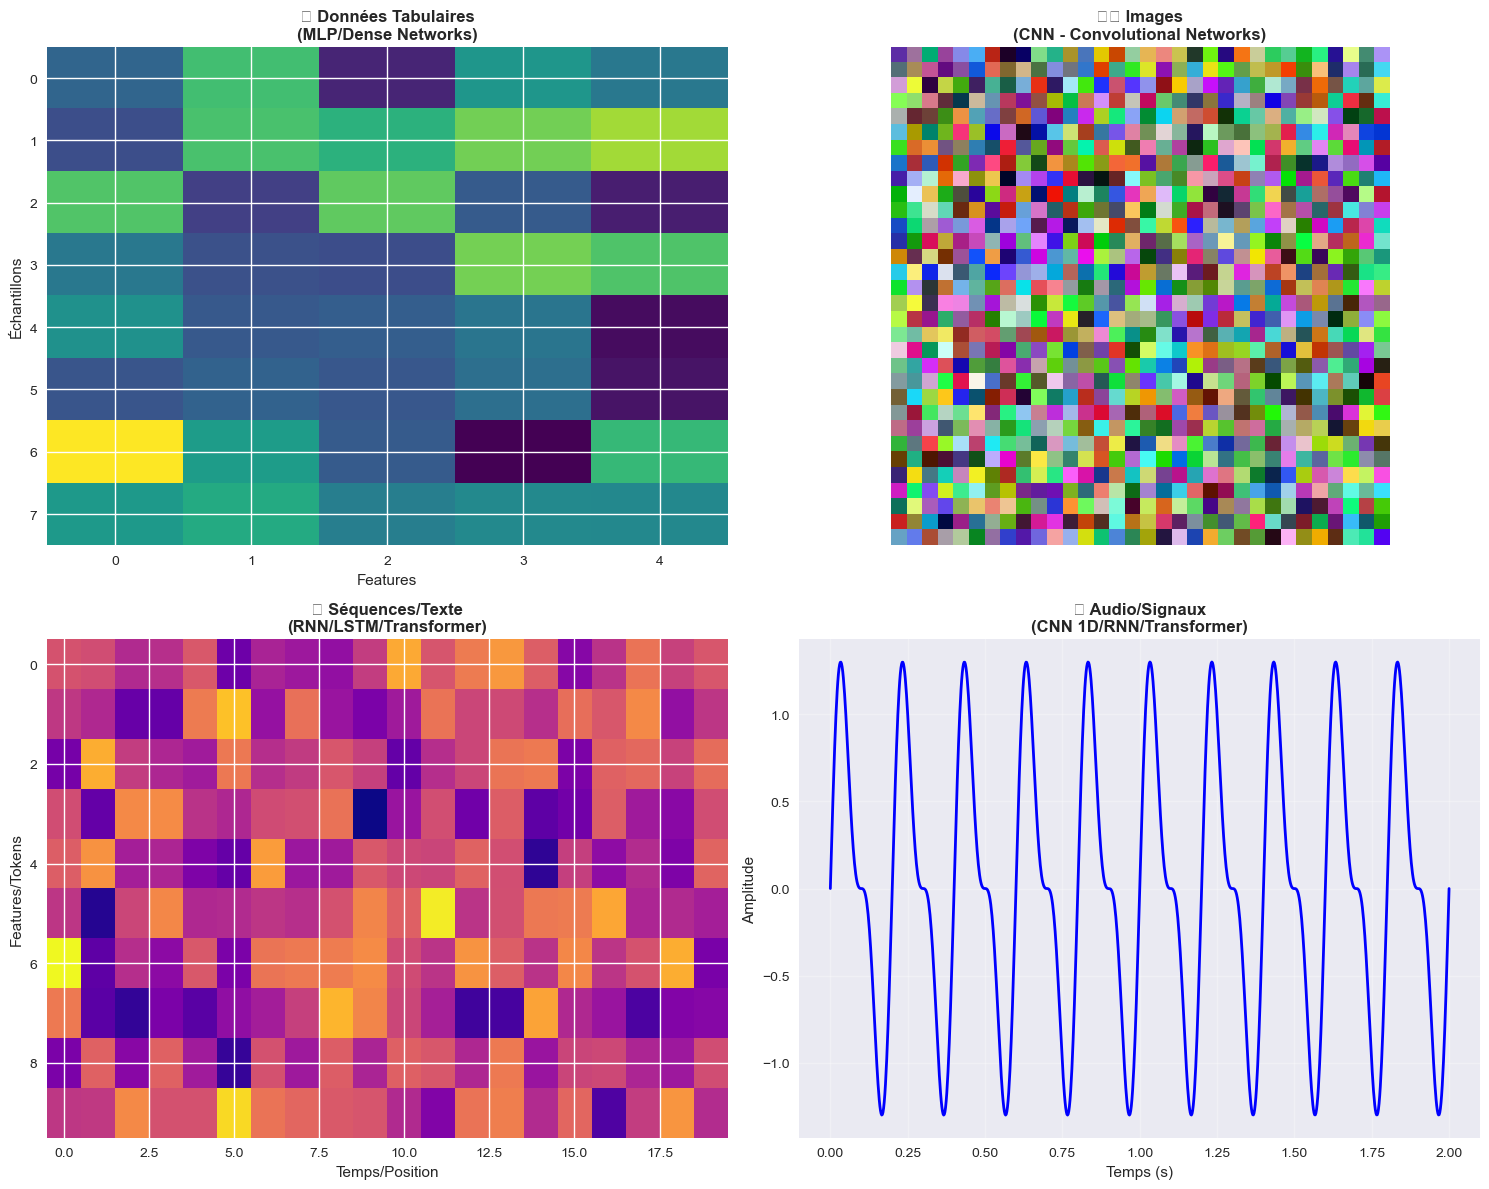

🎯 Chaque modalité nécessite une architecture spécialisée !


In [5]:
# Visualisation des modalités
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Données Tabulaires
ax1 = axes[0, 0]
data_tabular = np.random.randn(8, 5)
im1 = ax1.imshow(data_tabular, cmap='viridis', aspect='auto')
ax1.set_title('📊 Données Tabulaires\n(MLP/Dense Networks)', fontweight='bold')
ax1.set_xlabel('Features')
ax1.set_ylabel('Échantillons')

# 2. Images
ax2 = axes[0, 1]
# Simuler une image
image_data = np.random.rand(32, 32, 3)
ax2.imshow(image_data)
ax2.set_title('🖼️ Images\n(CNN - Convolutional Networks)', fontweight='bold')
ax2.axis('off')

# 3. Séquences/Texte
ax3 = axes[1, 0]
sequence_length = 20
sequence_data = np.random.randn(sequence_length, 10)
im3 = ax3.imshow(sequence_data.T, cmap='plasma', aspect='auto')
ax3.set_title('📝 Séquences/Texte\n(RNN/LSTM/Transformer)', fontweight='bold')
ax3.set_xlabel('Temps/Position')
ax3.set_ylabel('Features/Tokens')

# 4. Audio/Signal
ax4 = axes[1, 1]
time = np.linspace(0, 2, 1000)
signal = np.sin(2 * np.pi * 5 * time) + 0.5 * np.sin(2 * np.pi * 10 * time)
ax4.plot(time, signal, 'b-', linewidth=2)
ax4.set_title('🎵 Audio/Signaux\n(CNN 1D/RNN/Transformer)', fontweight='bold')
ax4.set_xlabel('Temps (s)')
ax4.set_ylabel('Amplitude')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🎯 Chaque modalité nécessite une architecture spécialisée !")

## 🖼️ 4. Vision par Ordinateur (Computer Vision)

### 🎯 Problèmes de Vision
- **Classification** : "Qu'est-ce que c'est ?"
- **Détection** : "Où sont les objets ?" (YOLO que nous avons vu)
- **Segmentation** : "Quels pixels appartiennent à quel objet ?"
- **Génération** : "Créer de nouvelles images"

### 🏗️ Architectures pour la Vision

🖼️ ARCHITECTURES DE COMPUTER VISION


,Architecture,Année,Paramètres (M),Top-1 Accuracy,Innovation Clé
0,LeNet-5,1998,0.06,99.2,Première CNN
1,AlexNet,2012,60.00,84.7,GPU + ReLU
2,VGG,2014,138.00,92.7,Profondeur
3,ResNet,2015,25.60,96.4,Skip connections
4,Inception,2015,23.00,96.9,Multi-échelle
5,EfficientNet,2019,5.30,97.1,Efficacité
6,Vision Transformer,2020,86.00,97.8,Attention pure


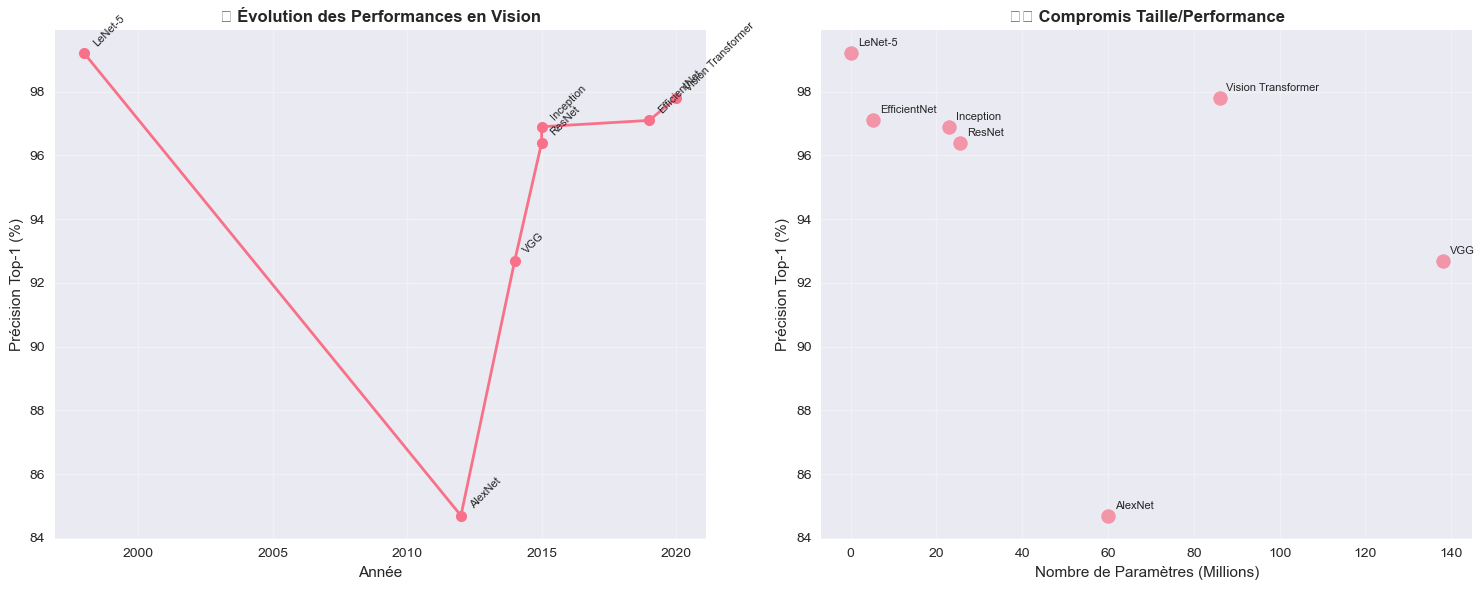

In [6]:
# Architectures de Computer Vision
cv_architectures = {
    'Architecture': ['LeNet-5', 'AlexNet', 'VGG', 'ResNet', 'Inception', 'EfficientNet', 'Vision Transformer'],
    'Année': [1998, 2012, 2014, 2015, 2015, 2019, 2020],
    'Paramètres (M)': [0.06, 60, 138, 25.6, 23, 5.3, 86],
    'Top-1 Accuracy': [99.2, 84.7, 92.7, 96.4, 96.9, 97.1, 97.8],
    'Innovation Clé': ['Première CNN', 'GPU + ReLU', 'Profondeur', 'Skip connections', 'Multi-échelle', 'Efficacité', 'Attention pure']
}

df_cv = pd.DataFrame(cv_architectures)
print("🖼️ ARCHITECTURES DE COMPUTER VISION")
print("=" * 50)
display(df_cv)

# Graphique évolution performances
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy vs Année
ax1.plot(df_cv['Année'], df_cv['Top-1 Accuracy'], 'o-', linewidth=2, markersize=8)
for i, arch in enumerate(df_cv['Architecture']):
    ax1.annotate(arch, (df_cv['Année'].iloc[i], df_cv['Top-1 Accuracy'].iloc[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=8, rotation=45)

ax1.set_xlabel('Année')
ax1.set_ylabel('Précision Top-1 (%)')
ax1.set_title('📈 Évolution des Performances en Vision', fontweight='bold')
ax1.grid(True, alpha=0.3)

# Paramètres vs Performance
ax2.scatter(df_cv['Paramètres (M)'], df_cv['Top-1 Accuracy'], s=100, alpha=0.7)
for i, arch in enumerate(df_cv['Architecture']):
    ax2.annotate(arch, (df_cv['Paramètres (M)'].iloc[i], df_cv['Top-1 Accuracy'].iloc[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax2.set_xlabel('Nombre de Paramètres (Millions)')
ax2.set_ylabel('Précision Top-1 (%)')
ax2.set_title('⚖️ Compromis Taille/Performance', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🖼️ Évolution des Architectures en Vision par Ordinateur

- **LeNet-5 (1998)** : première architecture CNN utilisée pour la reconnaissance de chiffres manuscrits, pionnière du deep learning.  
- **AlexNet (2012)** : révolutionne l’IA avec l’utilisation du GPU et de la fonction ReLU, gagnant d’ImageNet.  
- **VGG (2014)** : démontre que la profondeur des réseaux (beaucoup de couches convolutives) améliore la précision.  
- **ResNet (2015)** : introduit les *skip connections*, permettant d’entraîner des réseaux très profonds sans dégradation.  
- **Inception (2015)** : exploite des convolutions multi-échelles pour capturer différents niveaux de détails dans l’image.  
- **EfficientNet (2019)** : équilibre automatiquement largeur, profondeur et résolution pour atteindre une grande efficacité.  
- **Vision Transformer (2020)** : applique les Transformers au traitement d’images, basé uniquement sur l’attention.  


## 📝 5. Traitement du Langage Naturel (NLP)

### 🎯 Problèmes de NLP
- **Classification de texte** : Sentiment, spam, catégorie
- **Traduction** : D'une langue à une autre
- **Génération** : Écriture automatique, chatbots
- **Question-Réponse** : Compréhension et réponse

### 🏗️ Évolution des Architectures NLP

📝 ARCHITECTURES DE TRAITEMENT DU LANGAGE NATUREL


,Architecture,Année,Type,Avantage Principal,Limitation
0,RNN,1986,Récurrent,Simple,Gradient vanishing
1,LSTM,1997,Récurrent,Mémoire long terme,Lent
2,GRU,2014,Récurrent,Plus simple que LSTM,Moins puissant
3,Seq2Seq,2014,Encoder-Decoder,Séq vers séq,Goulot encoder
4,Attention,2015,Mécanisme,Focus sélectif,Complexité
5,Transformer,2017,Attention pure,Parallélisation,Beaucoup de données
6,BERT,2018,Bidirectionnel,Contexte bidirectionnel,Pas génératif
7,GPT,2018,Génératif,Génération fluide,Unidirectionnel
8,T5,2019,Text-to-Text,Polyvalent,Très gros


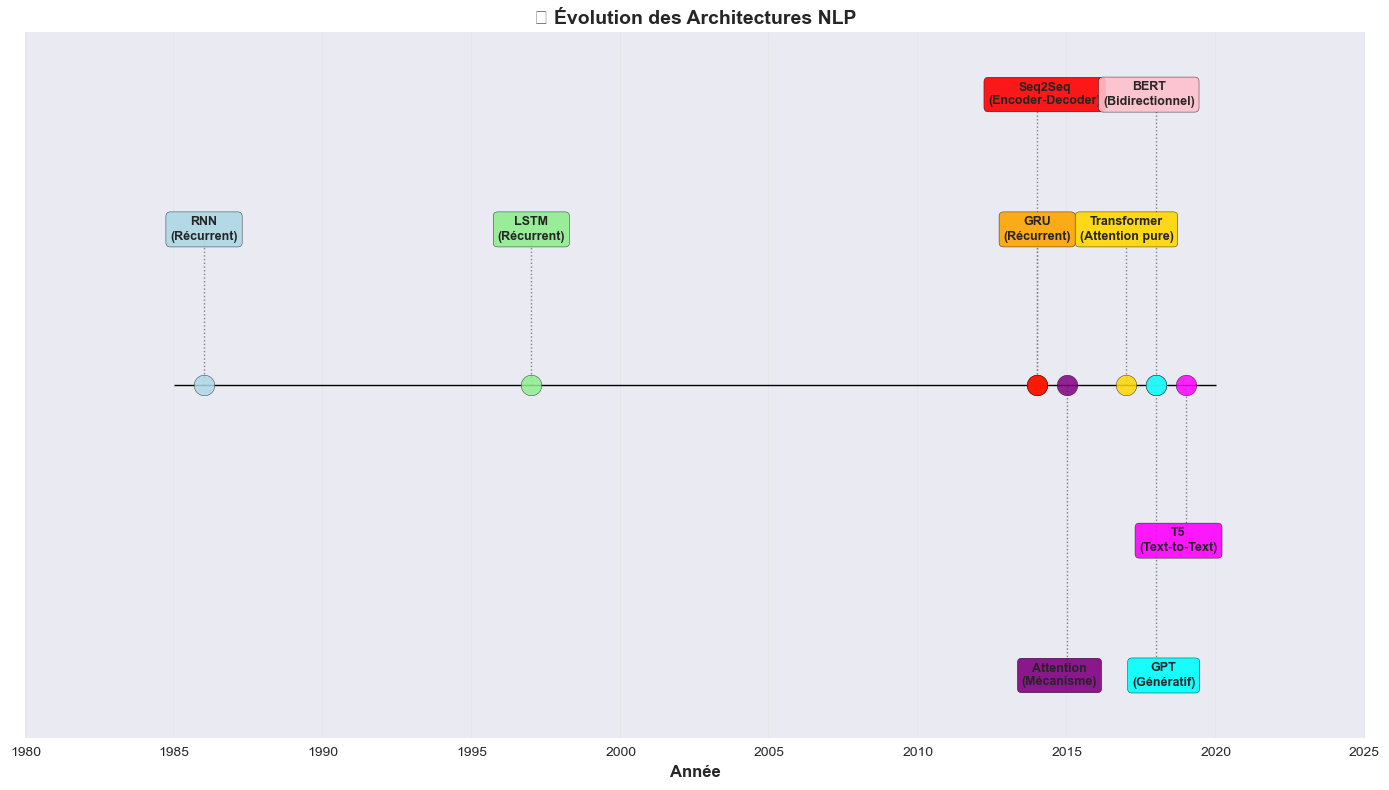

In [11]:
# --- Timeline NLP sans overlap ---


nlp_architectures = { 'Architecture': ['RNN', 'LSTM', 'GRU', 'Seq2Seq', 'Attention', 'Transformer', 'BERT', 'GPT', 'T5'],
                      'Année': [1986, 1997, 2014, 2014, 2015, 2017, 2018, 2018, 2019], 
                      'Type': ['Récurrent', 'Récurrent', 'Récurrent', 'Encoder-Decoder', 'Mécanisme', 'Attention pure', 'Bidirectionnel', 'Génératif', 'Text-to-Text'], 
                      'Avantage Principal': ['Simple', 'Mémoire long terme', 'Plus simple que LSTM', 'Séq vers séq', 'Focus sélectif', 'Parallélisation', 'Contexte bidirectionnel', 'Génération fluide', 'Polyvalent'], 'Limitation': ['Gradient vanishing', 'Lent', 'Moins puissant', 'Goulot encoder', 'Complexité', 'Beaucoup de données', 'Pas génératif', 'Unidirectionnel', 'Très gros'] }
df_nlp = pd.DataFrame(nlp_architectures)
print("📝 ARCHITECTURES DE TRAITEMENT DU LANGAGE NATUREL")
print("=" * 60) 
display(df_nlp)


fig, ax = plt.subplots(1, 1, figsize=(14, 8))

years  = df_nlp['Année'].to_list()
labels = df_nlp['Architecture'].to_list()
types  = df_nlp['Type'].to_list()
colors = ['lightblue','lightgreen','orange','red','purple','gold','pink','cyan','magenta']

y_timeline = 1.0
lanes = [0.72, 0.85, 1.15, 1.28]   # niveaux verticaux pour répartir les étiquettes
min_gap = 1                        # seuil (en années) pour changer de "lane"
assigned_y, lane_idx = [], 2       # 2 ~ proche de la ligne centrale

for i, yr in enumerate(years):
    if i > 0 and (yr - years[i-1]) <= min_gap:
        lane_idx = (lane_idx + 1) % len(lanes)   # alterner si années proches
    else:
        lane_idx = 2
    assigned_y.append(lanes[lane_idx])

# léger décalage horizontal pour les années identiques/proches
x_jitter = [0.0]*len(years)
for i in range(1, len(years)):
    if abs(years[i] - years[i-1]) <= min_gap:
        x_jitter[i] = 0.25 if (i % 2) else -0.25

# ligne de temps
ax.hlines(y=y_timeline, xmin=min(years)-1, xmax=max(years)+1, color='k', lw=1)

# points + étiquettes
for year, lab, typ, col, y_lab, dx in zip(years, labels, types, colors, assigned_y, x_jitter):
    # point sur la timeline
    ax.scatter(year, y_timeline, s=220, c=col, alpha=0.85, edgecolors='black', zorder=3)
    # trait de liaison
    ax.vlines(x=year, ymin=min(y_timeline, y_lab), ymax=max(y_timeline, y_lab),
              color='gray', lw=1, ls=':', zorder=1)
    # annotation (label + type)
    ax.annotate(f"{lab}\n({typ})",
                xy=(year, y_lab), xytext=(year+dx, y_lab),
                textcoords='data', ha='center', va='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.35', facecolor=col, alpha=0.9, edgecolor='black'))

# style
ax.set_xlim(1980, 2025)
ax.set_ylim(0.66, 1.34)
ax.set_xlabel('Année', fontsize=12, fontweight='bold')
ax.set_title('🕐 Évolution des Architectures NLP', fontsize=14, fontweight='bold')
ax.set_yticks([])
ax.grid(axis='x', alpha=0.25)

# repères de 5 ans (optionnel)
for yr in range(1980, 2026, 5):
    ax.axvline(yr, color='k', lw=0.3, alpha=0.12)

plt.tight_layout()
plt.show()


## 📝 Principales Architectures en NLP

- **RNN (Recurrent Neural Network, 1986)** : introduit la notion de mémoire pour traiter des séquences, mais limité par le problème du gradient qui disparaît.  
- **LSTM (Long Short-Term Memory, 1997)** : améliore les RNN en permettant de gérer des dépendances à long terme dans les textes ou séries temporelles.  
- **GRU (Gated Recurrent Unit, 2014)** : version simplifiée du LSTM, plus rapide à entraîner avec des performances proches.  
- **Seq2Seq (Encoder–Decoder, 2014)** : architecture clé pour la traduction automatique, transformant une séquence d’entrée en une séquence de sortie.  
- **Attention (2015)** : mécanisme qui permet au modèle de se concentrer sur les parties importantes d’une séquence lors du traitement.  
- **Transformer (2017)** : première architecture basée uniquement sur l’attention, permettant la parallélisation et des performances massives.  
- **BERT (Bidirectional Encoder Representations from Transformers, 2018)** : apprend le contexte dans les deux directions, devenu un standard pour la compréhension de texte.  
- **GPT (Generative Pre-trained Transformer, 2018)** : modèle génératif basé sur Transformer, capable de produire du texte fluide et cohérent.  
- **T5 (Text-to-Text Transfer Transformer, 2019)** : approche unifiée qui convertit toutes les tâches NLP en une tâche de traduction texte-à-texte.  


## 🎵 6. Traitement Audio et Signaux

### 🎯 Problèmes Audio
- **Reconnaissance vocale** : Speech-to-Text
- **Classification musicale** : Genre, émotion
- **Génération audio** : Synthèse vocale, musique
- **Détection d'événements** : Sons d'alarme, anomalies

### 🏗️ Approches pour l'Audio

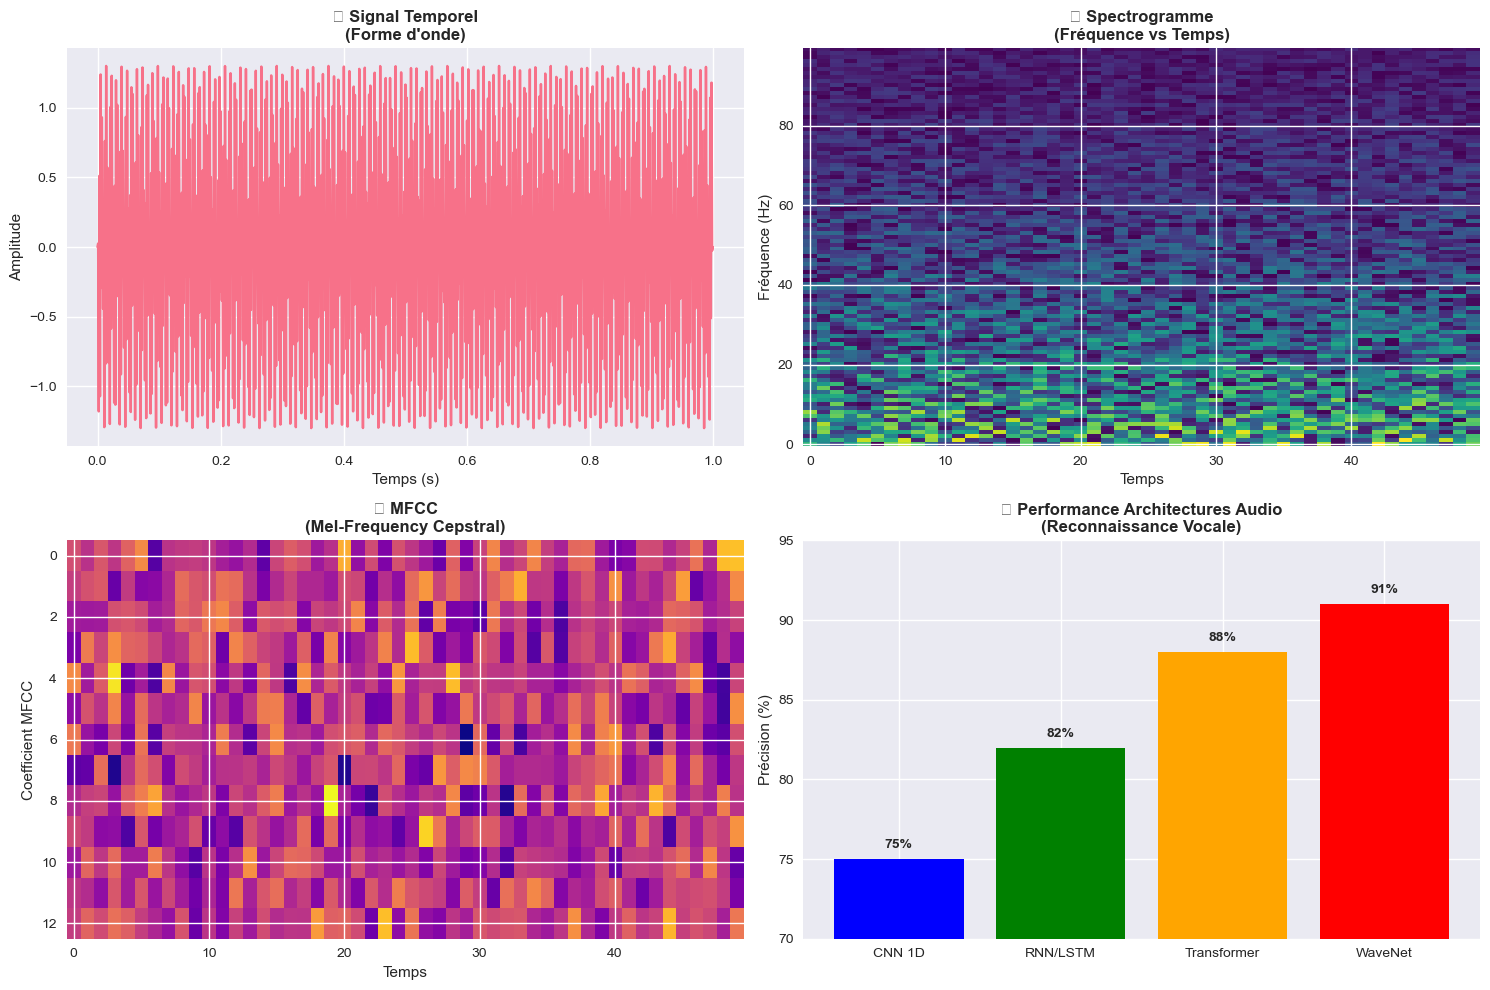


🎵 APPROCHES POUR LE TRAITEMENT AUDIO


,Représentation,Architecture,Avantage,Usage Principal
0,Signal brut,WaveNet/CNN 1D,Information complète,Génération audio
1,Spectrogramme,CNN 2D,Vision temps-fréquence,Classification
2,MFCC,MLP/RNN,"Compact, robuste",Reconnaissance vocale
3,Mel-spectrogramme,CNN 2D,Perception humaine,Musique/Parole


In [8]:
# Représentations audio
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Signal temporel
ax1 = axes[0, 0]
t = np.linspace(0, 1, 1000)
signal = np.sin(2*np.pi*440*t) + 0.5*np.sin(2*np.pi*880*t)  # La + octave
ax1.plot(t, signal)
ax1.set_title('🎵 Signal Temporel\n(Forme d\'onde)', fontweight='bold')
ax1.set_xlabel('Temps (s)')
ax1.set_ylabel('Amplitude')

# 2. Spectrogramme (simulation)
ax2 = axes[0, 1]
frequencies = np.linspace(0, 1000, 100)
time_spec = np.linspace(0, 1, 50)
spectrogram = np.random.rand(100, 50) * np.exp(-frequencies[:, None]/500)
im2 = ax2.imshow(spectrogram, aspect='auto', origin='lower', cmap='viridis')
ax2.set_title('📊 Spectrogramme\n(Fréquence vs Temps)', fontweight='bold')
ax2.set_xlabel('Temps')
ax2.set_ylabel('Fréquence (Hz)')

# 3. MFCC (simulation)
ax3 = axes[1, 0]
mfcc_data = np.random.randn(13, 50)  # 13 coefficients MFCC
im3 = ax3.imshow(mfcc_data, aspect='auto', cmap='plasma')
ax3.set_title('🎯 MFCC\n(Mel-Frequency Cepstral)', fontweight='bold')
ax3.set_xlabel('Temps')
ax3.set_ylabel('Coefficient MFCC')

# 4. Architectures audio
ax4 = axes[1, 1]
audio_archs = ['CNN 1D', 'RNN/LSTM', 'Transformer', 'WaveNet']
audio_performance = [75, 82, 88, 91]
bars = ax4.bar(audio_archs, audio_performance, color=['blue', 'green', 'orange', 'red'])
ax4.set_title('🏆 Performance Architectures Audio\n(Reconnaissance Vocale)', fontweight='bold')
ax4.set_ylabel('Précision (%)')
ax4.set_ylim(70, 95)

for bar, perf in zip(bars, audio_performance):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{perf}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Tableau des approches audio
audio_approaches = {
    'Représentation': ['Signal brut', 'Spectrogramme', 'MFCC', 'Mel-spectrogramme'],
    'Architecture': ['WaveNet/CNN 1D', 'CNN 2D', 'MLP/RNN', 'CNN 2D'],
    'Avantage': ['Information complète', 'Vision temps-fréquence', 'Compact, robuste', 'Perception humaine'],
    'Usage Principal': ['Génération audio', 'Classification', 'Reconnaissance vocale', 'Musique/Parole']
}

df_audio = pd.DataFrame(audio_approaches)
print("\n🎵 APPROCHES POUR LE TRAITEMENT AUDIO")
print("=" * 50)
display(df_audio)

## 🎶 Approches pour le Traitement Audio

- **Signal brut → WaveNet / CNN 1D** : exploite directement l’onde sonore complète pour capturer toute l’information, utilisé notamment pour la génération audio.  
- **Spectrogramme → CNN 2D** : transforme le signal en représentation temps–fréquence, idéal pour la classification de sons.  
- **MFCC (Mel-Frequency Cepstral Coefficients) → MLP / RNN** : représentation compacte et robuste, très efficace pour la reconnaissance vocale.  
- **Mel-spectrogramme → CNN 2D** : met en avant la perception humaine des fréquences, utilisé pour la musique et la parole.  


## 🌐 7. Apprentissage Multimodal

### 🎯 Qu'est-ce que le Multimodal ?
Combiner **plusieurs modalités** (texte + image + audio) pour une compréhension plus riche.

### 🚀 Exemples d'Applications Multimodales
- **CLIP** : Comprendre images et texte ensemble
- **DALL-E** : Générer images à partir de texte
- **GPT-4V** : Analyser images et répondre en texte
- **Flamingo** : Question-réponse sur images

🌐 MODÈLES MULTIMODAUX


,Modèle,Modalités,Tâche,Année,Organisation
0,CLIP,Texte + Image,Recherche,2021,OpenAI
1,DALL-E,Texte → Image,Génération,2021,OpenAI
2,DALL-E 2,Texte → Image,Génération,2022,OpenAI
3,Flamingo,Image + Texte,VQA,2022,DeepMind
4,GPT-4V,Image + Texte,Chat multimodal,2023,OpenAI
5,LLaVA,Image + Texte,Assistant visuel,2023,Microsoft


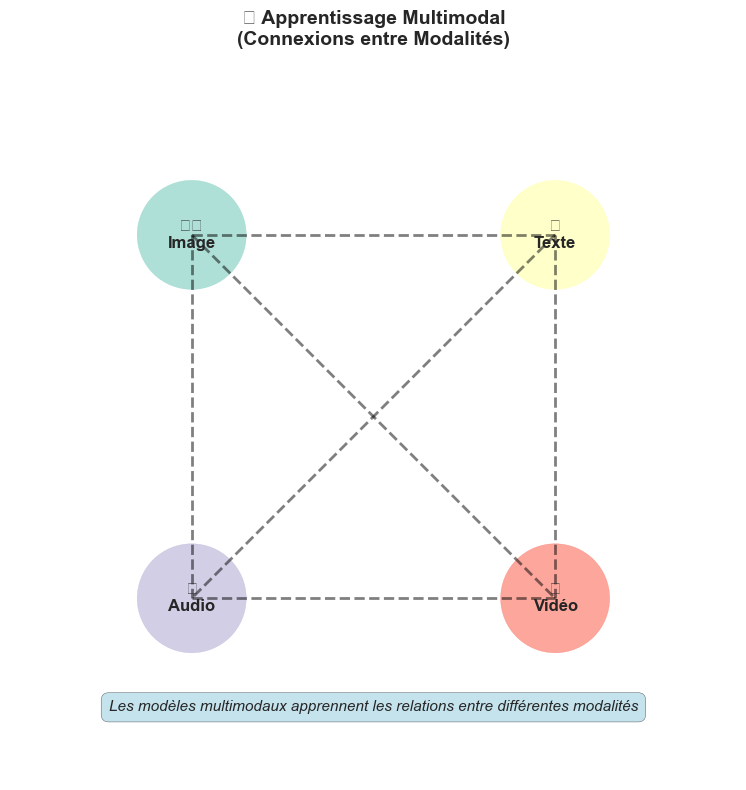

In [9]:
# Architectures multimodales
multimodal_data = {
    'Modèle': ['CLIP', 'DALL-E', 'DALL-E 2', 'Flamingo', 'GPT-4V', 'LLaVA'],
    'Modalités': ['Texte + Image', 'Texte → Image', 'Texte → Image', 'Image + Texte', 'Image + Texte', 'Image + Texte'],
    'Tâche': ['Recherche', 'Génération', 'Génération', 'VQA', 'Chat multimodal', 'Assistant visuel'],
    'Année': [2021, 2021, 2022, 2022, 2023, 2023],
    'Organisation': ['OpenAI', 'OpenAI', 'OpenAI', 'DeepMind', 'OpenAI', 'Microsoft']
}

df_multimodal = pd.DataFrame(multimodal_data)
print("🌐 MODÈLES MULTIMODAUX")
print("=" * 40)
display(df_multimodal)

# Diagramme des connexions multimodales
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Modalités
modalities = ['🖼️\nImage', '📝\nTexte', '🎵\nAudio', '📹\nVidéo']
positions = [(0, 1), (1, 1), (0, 0), (1, 0)]

# Dessiner les modalités
for i, (mod, pos) in enumerate(zip(modalities, positions)):
    circle = plt.Circle(pos, 0.15, color=plt.cm.Set3(i), alpha=0.7)
    ax.add_patch(circle)
    ax.text(pos[0], pos[1], mod, ha='center', va='center', fontsize=12, fontweight='bold')

# Connexions (apprentissage multimodal)
connections = [(0, 1), (0, 2), (1, 2), (1, 3), (0, 3), (2, 3)]
for i, j in connections:
    pos1, pos2 = positions[i], positions[j]
    ax.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]], 'k--', alpha=0.5, linewidth=2)

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_aspect('equal')
ax.set_title('🌐 Apprentissage Multimodal\n(Connexions entre Modalités)', fontsize=14, fontweight='bold')
ax.axis('off')

# Ajouter légende
ax.text(0.5, -0.3, 'Les modèles multimodaux apprennent les relations entre différentes modalités',
        ha='center', va='center', fontsize=11, style='italic',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.show()

## 🎯 8. Guide de Sélection d'Architecture

### 🤔 Comment Choisir la Bonne Architecture ?

#### 📊 **Données Tabulaires** (âge, prix, scores...)
- **MLP/Dense Networks** → Classification, régression simple
- **Exemple** : Prédire prix immobilier, diagnostic médical

#### 🖼️ **Images** (photos, radiographies, satellites...)
- **CNN** → Classification, détection, segmentation
- **Exemple** : Reconnaissance faciale, diagnostic médical

#### 📝 **Texte** (articles, emails, reviews...)
- **Transformer/BERT** → Classification, traduction, génération
- **Exemple** : Analyse sentiment, chatbot, traduction

#### 🎵 **Audio** (parole, musique, sons...)
- **CNN 1D + RNN** → Reconnaissance, classification
- **Exemple** : Speech-to-text, classification musicale

#### ⏰ **Séries Temporelles** (cours bourse, météo...)
- **LSTM/GRU** → Prédiction, détection anomalies
- **Exemple** : Prédiction météo, trading algorithmique

#### 🌐 **Multimodal** (image + texte, vidéo + audio...)
- **Architectures hybrides** → Compréhension riche
- **Exemple** : Description d'images, recherche multimédia

In [ ]:
# Matrice de décision
decision_matrix = {
    'Type de Données': ['Tabulaires', 'Images', 'Texte', 'Audio', 'Séries Temporelles', 'Multimodal'],
    'Architecture Recommandée': ['MLP/Dense', 'CNN', 'Transformer', 'CNN 1D + RNN', 'LSTM/GRU', 'Hybride'],
    'Complexité': ['Faible', 'Moyenne', 'Élevée', 'Moyenne', 'Moyenne', 'Très élevée'],
    'Temps d\'Entraînement': ['Court', 'Moyen', 'Long', 'Moyen', 'Moyen', 'Très long'],
    'Données Requises': ['Peu', 'Beaucoup', 'Énormément', 'Beaucoup', 'Moyennement', 'Énormément']
}

df_decision = pd.DataFrame(decision_matrix)
print("🎯 GUIDE DE SÉLECTION D'ARCHITECTURE")
print("=" * 50)
display(df_decision)

# Graphique radar des caractéristiques
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Caractéristiques à évaluer
categories = ['Simplicité', 'Vitesse', 'Précision', 'Flexibilité', 'Interprétabilité']
N = len(categories)

# Architectures à comparer
architectures_radar = {
    'MLP': [5, 5, 3, 3, 4],
    'CNN': [3, 4, 5, 4, 2],
    'Transformer': [2, 2, 5, 5, 1]
}

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Fermer le cercle

colors = ['blue', 'red', 'green']
for i, (arch, values) in enumerate(architectures_radar.items()):
    values += values[:1]  # Fermer le cercle
    ax.plot(angles, values, 'o-', linewidth=2, label=arch, color=colors[i])
    ax.fill(angles, values, alpha=0.25, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 5)
ax.set_title('📊 Comparaison des Architectures\n(1=Faible, 5=Élevé)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.grid(True)

plt.tight_layout()
plt.show()

## 🎓 Résumé de la Partie 1

### ✅ Ce que nous avons appris :

1. **📈 Évolution Historique** : Du perceptron (1943) aux transformers (2017+)

2. **🏗️ Architectures Spécialisées** :
   - **MLP** : Données tabulaires
   - **CNN** : Images et vision
   - **RNN/LSTM** : Séquences et temps
   - **Transformer** : Texte et attention

3. **🎨 Modalités de Données** :
   - **Texte** → NLP avec Transformers
   - **Image** → Computer Vision avec CNN
   - **Audio** → Traitement signal avec CNN 1D
   - **Multimodal** → Architectures hybrides

4. **🎯 Guide de Sélection** : Choisir l'architecture selon le type de données

### 🚀 Dans la Partie 2, nous verrons :
- **Hardware** : CPU vs GPU vs Multi-GPU
- **Transfer Learning** : Réutiliser des modèles pré-entraînés
- **Transformers** : Architecture révolutionnaire en détail
- **Benchmarks** : Comment comparer et choisir les algorithmes

---
**🎉 Vous maîtrisez maintenant les architectures de deep learning !**

In [ ]:
print("🎓 PARTIE 1 TERMINÉE !")
print("=" * 30)
print("✅ Architectures comprises")
print("✅ Modalités identifiées") 
print("✅ Guide de sélection acquis")
print("\n🚀 Prêt pour la Partie 2 : Hardware et Optimisation !")